<a href="https://colab.research.google.com/github/SAGNIK890/NXP-Aim-Buggy/blob/main/Module1_improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip -q install kagglehub python-docx python-pptx

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings("ignore")
OUT = "outputs"
os.makedirs(OUT, exist_ok=True)
CLASS_ORDER = ["Healthy", "Degrading", "Critical"]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 19.6 MB/s eta 0:00:00


In [ ]:

import kagglehub


path = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")
print("Path to dataset files:", path)


meta_files = glob.glob(os.path.join(path, "**", "metadata.csv"), recursive=True)
assert meta_files, "metadata.csv not found - check the folder structure printed below"
DATA_ROOT = os.path.dirname(meta_files[0])
print("Dataset root:", DATA_ROOT)

meta = pd.read_csv(meta_files[0])
print("\nMetadata shape:", meta.shape)
print(meta.head())
print("\nTest types:\n", meta["type"].value_counts())

Using Colab cache for faster access to the 'nasa-battery-dataset' dataset.
Path to dataset files: /kaggle/input/nasa-battery-dataset
Dataset root: /kaggle/input/nasa-battery-dataset/cleaned_dataset

Metadata shape: (7565, 10)
        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   
1  impedance  [2010.       7.      21.      16.      53.    ...   
2     charge  [2010.       7.      21.      17.      25.    ...   
3  impedance                    [2010    7   21   20   31    5]   
4  discharge  [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   
1                   24      B0047        1    2  00002.csv   
2                    4      B0047        2    3  00003.csv   
3                   24      B0047        3    4  00004.csv   
4                    4      B0047        4    5  00005.csv   

In [ ]:

dis = meta[meta["type"] == "discharge"].copy()
dis["Capacity"] = pd.to_numeric(dis["Capacity"], errors="coerce")
dis["ambient_temperature"] = pd.to_numeric(dis["ambient_temperature"], errors="coerce")

sort_cols = [c for c in ["battery_id", "test_id", "uid"] if c in dis.columns]
dis = dis.sort_values(sort_cols).reset_index(drop=True)
dis["cycle"] = dis.groupby("battery_id").cumcount() + 1
print("Discharge cycles:", len(dis), "| batteries:", dis["battery_id"].nunique())

Discharge cycles: 2794 | batteries: 34


In [ ]:

def find_file(fname):
    p = os.path.join(DATA_ROOT, "data", fname)
    if os.path.exists(p):
        return p
    hits = glob.glob(os.path.join(DATA_ROOT, "**", fname), recursive=True)
    return hits[0] if hits else None


def extract_features(fp):
    d = pd.read_csv(fp)
    v, t = d["Voltage_measured"], d["Time"]
    cur, temp = d["Current_measured"], d["Temperature_measured"]
    below = t[v < 3.5]
    dt = t.diff().fillna(0)
    cap_est = (cur.abs() * dt).sum() / 3600
    energy = (cur.abs() * v * dt).sum() / 3600
    return {
        "cap_est_ah": cap_est, "energy_wh": energy,
        "v_mean": v.mean(), "v_min": v.min(), "v_max": v.max(), "v_std": v.std(),
        "i_mean": cur.mean(),
        "temp_mean": temp.mean(), "temp_max": temp.max(),
        "temp_rise": temp.max() - temp.iloc[0],
        "discharge_time_s": t.max(),
        "time_to_3_5V_s": below.iloc[0] if len(below) else t.max(),
    }


rows = []
for _, r in dis.iterrows():
    fp = find_file(r["filename"])
    if fp is None:
        continue
    try:
        feats = extract_features(fp)
    except Exception:
        continue
    feats.update({"battery_id": r["battery_id"], "cycle": r["cycle"],
                  "ambient_temperature": r["ambient_temperature"],
                  "capacity_ah": r["Capacity"]})
    rows.append(feats)

df = pd.DataFrame(rows)
print("Raw feature table:", df.shape)

Raw feature table: (2794, 16)


In [ ]:

n_raw = len(df)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
df = df.drop_duplicates()
df = df[(df["capacity_ah"] > 0.2) & (df["capacity_ah"] < 2.5)]
df = df[df["discharge_time_s"] > 60]
df = df.sort_values(["battery_id", "cycle"]).reset_index(drop=True)

BASE_COLS = ["cap_est_ah", "energy_wh", "discharge_time_s", "time_to_3_5V_s", "v_mean"]
for c in BASE_COLS:
    base = df.groupby("battery_id")[c].transform(lambda s: s.iloc[:3].median())
    df[f"{c}_rel"] = df[c] / base


initial_cap = df.groupby("battery_id")["capacity_ah"].transform(lambda s: s.iloc[:3].median())
df["soh"] = df["capacity_ah"] / initial_cap


HEALTHY_MIN, DEGRADING_MIN = 0.85, 0.75


def label_health(soh):
    if soh >= HEALTHY_MIN:
        return "Healthy"
    if soh >= DEGRADING_MIN:
        return "Degrading"
    return "Critical"


df["health_status"] = df["soh"].apply(label_health)
print(f"Rows: raw={n_raw}, after cleaning={len(df)}")
print(df["health_status"].value_counts())

Rows: raw=2794, after cleaning=2562
health_status
Healthy      1638
Degrading     658
Critical      266
Name: count, dtype: int64


In [ ]:

df.to_csv(f"{OUT}/cleaned_battery_dataset.csv", index=False)
stats = df.describe().T
stats.to_csv(f"{OUT}/basic_statistics.csv")
print(stats.round(3))

                       count      mean       std      min       25%       50%  \
cap_est_ah            2562.0     1.488     0.285    0.226     1.306     1.512   
energy_wh             2562.0     4.982     1.097    0.655     4.234     5.024   
v_mean                2562.0     3.415     0.121    2.883     3.368     3.412   
v_min                 2562.0     2.319     0.294    0.193     2.070     2.384   
v_max                 2562.0     4.186     0.032    3.758     4.182     4.187   
v_std                 2562.0     0.296     0.072    0.152     0.241     0.270   
i_mean                2562.0    -1.760     0.690   -3.976    -1.940    -1.802   
temp_mean             2562.0    28.237    13.486    7.677    12.215    31.818   
temp_max              2562.0    35.973    15.700   10.149    19.190    38.304   
temp_rise             2562.0    15.445     7.754    1.255    10.829    14.582   
discharge_time_s      2562.0  3407.751  1269.503  982.938  2806.176  3058.812   
time_to_3_5V_s        2562.0

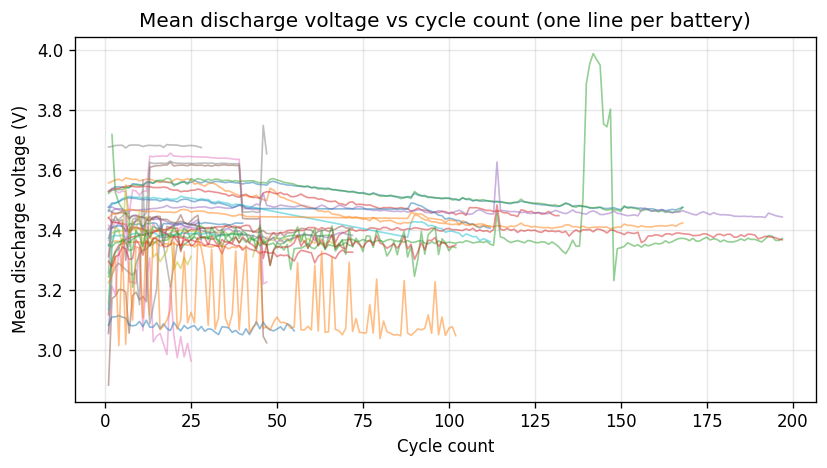

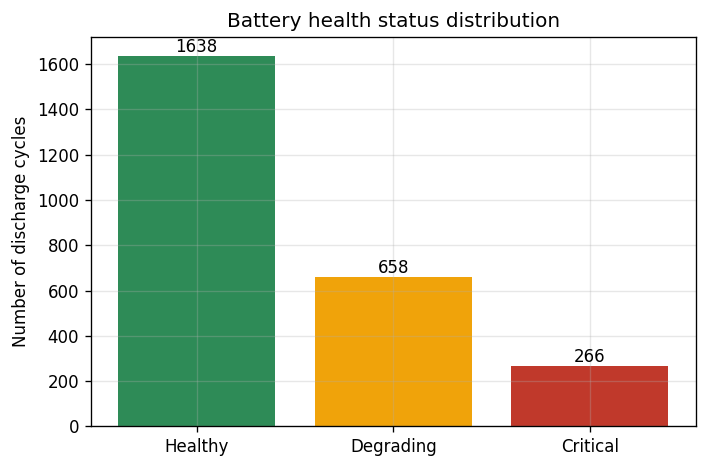

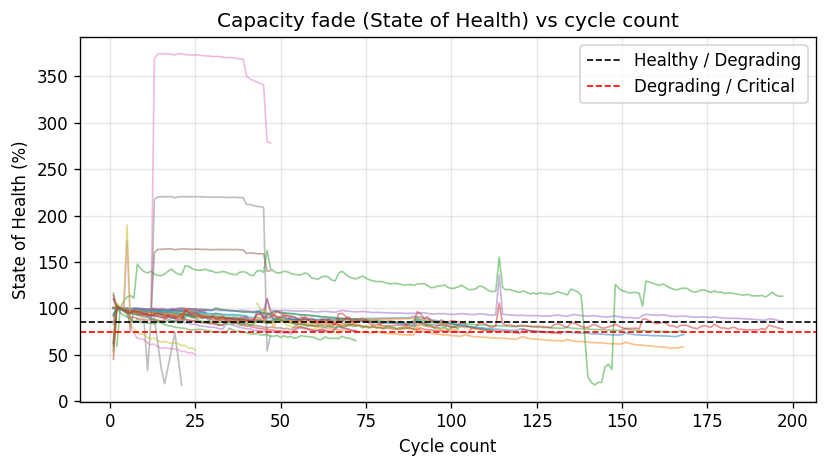

In [ ]:

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": .3})
colors = {"Healthy": "#2e8b57", "Degrading": "#f0a30a", "Critical": "#c0392b"}


fig, ax = plt.subplots(figsize=(7, 4))
for b, g in df.groupby("battery_id"):
    ax.plot(g["cycle"], g["v_mean"], alpha=.5, lw=1)
ax.set_xlabel("Cycle count"); ax.set_ylabel("Mean discharge voltage (V)")
ax.set_title("Mean discharge voltage vs cycle count (one line per battery)")
fig.tight_layout(); fig.savefig(f"{OUT}/chart1_voltage_vs_cycle.png"); plt.show()


fig, ax = plt.subplots(figsize=(6, 4))
counts = df["health_status"].value_counts().reindex(CLASS_ORDER).fillna(0)
bars = ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
ax.bar_label(bars)
ax.set_ylabel("Number of discharge cycles"); ax.set_title("Battery health status distribution")
fig.tight_layout(); fig.savefig(f"{OUT}/chart2_health_distribution.png"); plt.show()


fig, ax = plt.subplots(figsize=(7, 4))
for b, g in df.groupby("battery_id"):
    ax.plot(g["cycle"], g["soh"] * 100, alpha=.5, lw=1)
ax.axhline(HEALTHY_MIN * 100, color="k", ls="--", lw=1, label="Healthy / Degrading")
ax.axhline(DEGRADING_MIN * 100, color="r", ls="--", lw=1, label="Degrading / Critical")
ax.set_xlabel("Cycle count"); ax.set_ylabel("State of Health (%)")
ax.set_title("Capacity fade (State of Health) vs cycle count"); ax.legend()
fig.tight_layout(); fig.savefig(f"{OUT}/chart3_capacity_fade.png"); plt.show()

Train: (1962, 19) | Test: (600, 19)
Test batteries: ['B0007', 'B0031', 'B0032', 'B0039', 'B0040', 'B0043', 'B0048', 'B0049', 'B0054']
                 cv_acc  test_acc test_macro_f1  \
SVM (RBF)      0.895239  0.853333      0.764765   
Decision Tree  0.947409     0.895      0.910263   

                                                          params  
SVM (RBF)                    {'clf__C': 100, 'clf__gamma': 0.01}  
Decision Tree  {'criterion': 'entropy', 'max_depth': 5, 'min_...  

Previous Random Forest baseline (original run): accuracy = 0.7850

Selected model: Decision Tree  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5}

Accuracy: 0.8950

              precision    recall  f1-score   support

     Healthy       0.89      0.96      0.92       394
   Degrading       0.90      0.73      0.81       181
    Critical       1.00      1.00      1.00        25

    accuracy                           0.90       600
   macro avg       0.93      0.90      0.91       600
wei

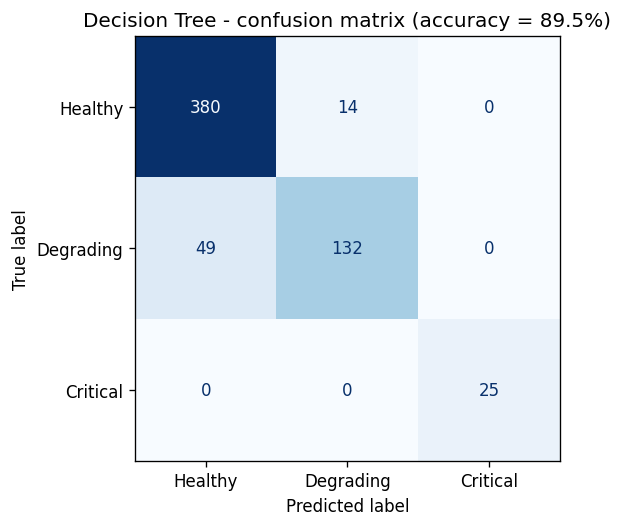


Top features (permutation importance on test set):
 cap_est_ah_rel    0.352
v_mean            0.066
energy_wh_rel     0.045
energy_wh         0.033
time_to_3_5V_s    0.028
dtype: float64


In [ ]:

from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, GroupKFold, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score


RAW_FEATURES = ["cycle", "ambient_temperature", "v_mean", "v_min", "v_max", "v_std",
                "i_mean", "temp_mean", "temp_max", "temp_rise",
                "discharge_time_s", "time_to_3_5V_s"]
EXTRA_FEATURES = ["cap_est_ah", "energy_wh"] + [f"{c}_rel" for c in BASE_COLS]


USE_CAPACITY_PROXY = True
PROXY = ["cap_est_ah", "energy_wh", "cap_est_ah_rel", "energy_wh_rel"]
FEATURES = [f for f in RAW_FEATURES + EXTRA_FEATURES if USE_CAPACITY_PROXY or f not in PROXY]

X, y, groups = df[FEATURES], df["health_status"], df["battery_id"]


present = set(y.unique())
split_ok = False
for seed in range(200):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=seed)
    tr, te = next(gss.split(X, y, groups))
    if set(y.iloc[tr]) == present and set(y.iloc[te]) == present:
        split_ok = True
        break
if not split_ok:
    tr, te = train_test_split(np.arange(len(df)), test_size=0.25, stratify=y, random_state=42)
    print("Group split failed -> used stratified random split")

X_train, X_test, y_train, y_test = X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te]
g_train = groups.iloc[tr]
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Test batteries:", sorted(groups.iloc[te].unique()))


cv = GroupKFold(n_splits=5)
candidates = {
    "SVM (RBF)": GridSearchCV(
        Pipeline([("scale", StandardScaler()),
                  ("clf", SVC(kernel="rbf", class_weight="balanced",
                              probability=True, random_state=42))]),
        {"clf__C": [1, 10, 100], "clf__gamma": ["scale", 0.01, 0.1]},
        cv=cv, scoring="accuracy", n_jobs=-1),
    "Decision Tree": GridSearchCV(
        DecisionTreeClassifier(class_weight="balanced", random_state=42),
        {"max_depth": [3, 4, 5, 6, 8, None], "min_samples_leaf": [1, 5, 10, 20],
         "criterion": ["gini", "entropy"]},
        cv=cv, scoring="accuracy", n_jobs=-1),
}

labels = [c for c in CLASS_ORDER if c in present]
results = {}
for name, gs in candidates.items():
    gs.fit(X_train, y_train, groups=g_train)
    pred = gs.predict(X_test)
    results[name] = {"cv_acc": gs.best_score_,
                     "test_acc": accuracy_score(y_test, pred),
                     "test_macro_f1": f1_score(y_test, pred, average="macro", labels=labels, zero_division=0),
                     "params": gs.best_params_}

print(pd.DataFrame(results).T[["cv_acc", "test_acc", "test_macro_f1", "params"]])
print("\nPrevious Random Forest baseline (original run): accuracy = 0.7850")

# pick the winner on cross-validated accuracy (not on the test set)
best_name = max(results, key=lambda k: results[k]["cv_acc"])
model = candidates[best_name].best_estimator_
print(f"\nSelected model: {best_name}  {results[best_name]['params']}")

joblib.dump(model, f"{OUT}/battery_health_model.joblib")
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred, labels=labels)

print(f"\nAccuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
ax.grid(False); ax.set_title(f"{best_name} - confusion matrix (accuracy = {acc:.1%})")
fig.tight_layout(); fig.savefig(f"{OUT}/confusion_matrix.png"); plt.show()

# permutation importance works for both SVM and trees
pi = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
importances = pd.Series(pi.importances_mean, index=FEATURES).sort_values(ascending=False)
print("\nTop features (permutation importance on test set):\n", importances.head(5).round(3))


In [ ]:
model = joblib.load(f"{OUT}/battery_health_model.joblib")

# Fallback "new battery" reference used only when no baseline is given for a battery
DEFAULT_BASELINE = (df.groupby("battery_id")[BASE_COLS]
                      .apply(lambda g: g.iloc[:3].median()).median().to_dict())


def battery_baseline(battery_id):
    """Median of a battery's first 3 discharge cycles (its 'as new' reference)."""
    first = df[df["battery_id"] == battery_id].sort_values("cycle").iloc[:3]
    return first[BASE_COLS].median().to_dict()


def predict_health(sample, baseline=None):
    """sample = dict with the raw features. baseline = that battery's first-cycles reference
    (see battery_baseline). Returns (prediction, probabilities)."""
    baseline = baseline or DEFAULT_BASELINE
    s = dict(sample)
    for c in BASE_COLS:
        s[f"{c}_rel"] = s[c] / baseline[c]
    row = pd.DataFrame([s])[FEATURES]
    pred = model.predict(row)[0]
    proba = {c: round(float(p), 3) for c, p in zip(model.classes_, model.predict_proba(row)[0])}
    return pred, proba


demo = X_test.sample(8, random_state=1)
res = pd.DataFrame({"cycle": demo["cycle"].values,
                    "true_status": y_test.loc[demo.index].values,
                    "predicted": model.predict(demo)})
res["correct"] = res["true_status"] == res["predicted"]
print(res, "\n")


my_battery = {"cycle": 120, "ambient_temperature": 24,
              "v_mean": 3.50, "v_min": 2.70, "v_max": 4.20, "v_std": 0.35,
              "i_mean": -2.0, "temp_mean": 32.0, "temp_max": 38.0, "temp_rise": 12.0,
              "discharge_time_s": 2600, "time_to_3_5V_s": 1500,
              "cap_est_ah": 1.44, "energy_wh": 5.0}
pred, proba = predict_health(my_battery)      # uses DEFAULT_BASELINE (no battery history given)
print("Custom battery ->", pred, proba)


def predict_from_file(csv_path, cycle, ambient_temperature=24, baseline=None):
    feats = extract_features(csv_path)
    feats.update({"cycle": cycle, "ambient_temperature": ambient_temperature})
    return predict_health(feats, baseline)


b = dis["battery_id"].iloc[0]
b_rows = dis[dis["battery_id"] == b]
for label, r in [("early", b_rows.iloc[2]), ("late", b_rows.iloc[-2])]:
    print(b, label, "cycle", r["cycle"], "->",
          predict_from_file(find_file(r["filename"]), r["cycle"], r["ambient_temperature"],
                            baseline=battery_baseline(b)))


print(sorted(os.listdir(OUT)))
try:
    import shutil
    from google.colab import files
    shutil.make_archive("ev_battery_outputs", "zip", OUT)
    files.download("ev_battery_outputs.zip")
except ImportError:
    print("Not running in Colab - files are in the 'outputs' folder.")


   cycle true_status  predicted  correct
0     43   Degrading  Degrading     True
1    112   Degrading  Degrading     True
2     12     Healthy    Healthy     True
3     52   Degrading  Degrading     True
4     34     Healthy    Healthy     True
5     24     Healthy    Healthy     True
6     11     Healthy    Healthy     True
7     51     Healthy    Healthy     True 

Custom battery -> Degrading {'Critical': 0.0, 'Degrading': 0.984, 'Healthy': 0.016}
B0005 early cycle 3 -> ('Healthy', {'Critical': 0.0, 'Degrading': 0.0, 'Healthy': 1.0})
B0005 late cycle 167 -> ('Critical', {'Critical': 1.0, 'Degrading': 0.0, 'Healthy': 0.0})
['basic_statistics.csv', 'battery_health_model.joblib', 'chart1_voltage_vs_cycle.png', 'chart2_health_distribution.png', 'chart3_capacity_fade.png', 'cleaned_battery_dataset.csv', 'confusion_matrix.png']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Full-dataset preprocessing (moved to the end)
This cell redefines `df` and `find_file`, so it has to run *after* the modelling cells.

In [ ]:


import os
import re
import numpy as np
import pandas as pd
import kagglehub
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)
ORIGINAL_CSV = os.path.join(OUT_DIR, "nasa_battery_original.csv")
CLEANED_CSV = os.path.join(OUT_DIR, "nasa_battery_cleaned.csv")

path = kagglehub.dataset_download("patrickfleith/nasa-battery-dataset")
print("Path to dataset files:", path)


def find_file(root, name):
    for dp, _, files in os.walk(root):
        if name in files:
            return os.path.join(dp, name)
    return None


meta_path = find_file(path, "metadata.csv")
if meta_path is None:
    raise FileNotFoundError("metadata.csv not found. Inspect the folder: " + path)
data_dir = os.path.join(os.path.dirname(meta_path), "data")
if not os.path.isdir(data_dir):
    data_dir = os.path.dirname(meta_path)
print("metadata:", meta_path)
print("data dir:", data_dir)


meta_raw = pd.read_csv(meta_path)
print("Metadata shape:", meta_raw.shape)
print(meta_raw.head())


def build_original(meta, data_dir, out_csv):
    """Stream every cycle file, attach its metadata row, append to one CSV."""
    if os.path.exists(out_csv):
        os.remove(out_csv)
    first = True
    total = 0
    frames_for_memory = []
    for _, row in meta.iterrows():
        fpath = os.path.join(data_dir, str(row["filename"]))
        if not os.path.exists(fpath):
            continue
        df = pd.read_csv(fpath)
        for col in meta.columns:               # attach metadata to every row
            df[col] = row[col]
        df.to_csv(out_csv, mode="a", header=first, index=False)
        first = False
        total += len(df)
        frames_for_memory.append(df)
    print(f"Original dataset saved -> {out_csv}  ({total:,} rows)")
    return pd.concat(frames_for_memory, ignore_index=True)


original = build_original(meta_raw, data_dir, ORIGINAL_CSV)


df = original.copy()


df.columns = [c.strip().replace(" ", "_") for c in df.columns]

def parse_start_time(s):
    """'[2008.  4.  2. 15. 25. 41.]' -> Timestamp"""
    nums = re.findall(r"[-+]?\d*\.?\d+", str(s))
    if len(nums) < 6:
        return pd.NaT
    y, mo, d, h, mi, sec = [int(float(n)) for n in nums[:6]]
    try:
        return pd.Timestamp(y, mo, d, h, mi, sec)
    except ValueError:
        return pd.NaT


if "start_time" in df.columns:
    df["start_time"] = df["start_time"].apply(parse_start_time)
    df["start_year"] = df["start_time"].dt.year
    df["start_month"] = df["start_time"].dt.month
    df["start_dayofyear"] = df["start_time"].dt.dayofyear
    df["start_hour"] = df["start_time"].dt.hour

for col in ["Capacity", "Re", "Rct", "ambient_temperature"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df):,} duplicate rows")


drop_cols = [c for c in ["filename", "uid", "test_id", "start_time"] if c in df.columns]
df = df.drop(columns=drop_cols)


cat_cols = [c for c in ["type", "battery_id"] if c in df.columns]
for c in cat_cols:
    df[c] = df[c].astype(str).str.strip().str.lower()

num_cols = [c for c in df.select_dtypes(include=[np.number]).columns]


print("\nMissing values before imputation:\n", df[num_cols].isna().sum()[lambda s: s > 0])
for c in num_cols:
    if df[c].isna().any():
        df[f"{c}_missing"] = df[c].isna().astype(np.int8)
        if "type" in df.columns:
            df[c] = df[c].fillna(df.groupby("type")[c].transform("median"))
        df[c] = df[c].fillna(df[c].median()).fillna(0)


signal_cols = [c for c in ["Voltage_measured", "Current_measured", "Temperature_measured",
                           "Current_charge", "Voltage_charge", "Current_load", "Voltage_load",
                           "Sense_current", "Battery_current", "Current_ratio",
                           "Battery_impedance", "Rectified_Impedance", "Capacity", "Re", "Rct"]
               if c in df.columns]
for c in signal_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    df[c] = df[c].clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)


if {"Voltage_measured", "Current_measured"}.issubset(df.columns):
    df["Power_measured"] = df["Voltage_measured"] * df["Current_measured"]
if "Time" in df.columns and "battery_id" in df.columns:
    df["Time_delta"] = df.groupby("battery_id")["Time"].diff().fillna(0)


if "type" in df.columns:
    df = pd.concat([df, pd.get_dummies(df["type"], prefix="type", dtype=np.int8)], axis=1)


if {"type", "ambient_temperature"}.issubset(df.columns):
    temp_group = df["ambient_temperature"].round().astype(int).astype(str).radd("temp_")
    two_hot = pd.get_dummies(df["type"].radd("type_"), dtype=np.int8).join(
        pd.get_dummies(temp_group, dtype=np.int8), how="left", rsuffix="_t")
    two_hot.columns = [f"twohot_{c}" for c in two_hot.columns]
    df = pd.concat([df, two_hot], axis=1)
if "battery_id" in df.columns:
    df["battery_id_label"] = LabelEncoder().fit_transform(df["battery_id"])
    df = pd.concat([df, pd.get_dummies(df["battery_id"], prefix="battery", dtype=np.int8)], axis=1)


scale_cols = [c for c in signal_cols + ["Time", "Power_measured", "Time_delta",
                                        "ambient_temperature", "start_year",
                                        "start_month", "start_dayofyear", "start_hour"]
              if c in df.columns]


std = StandardScaler()
std_vals = std.fit_transform(df[scale_cols].astype(np.float64))
df[[f"{c}_std" for c in scale_cols]] = std_vals.astype(np.float32)


mm = MinMaxScaler()
mm_vals = mm.fit_transform(df[scale_cols].astype(np.float64))
df[[f"{c}_norm" for c in scale_cols]] = mm_vals.astype(np.float32)


df.to_csv(CLEANED_CSV, index=False)
print(f"\nCleaned dataset saved -> {CLEANED_CSV}  shape={df.shape}")
print(df.head())

print("\nDone.")
print("  Original:", ORIGINAL_CSV)
print("  Cleaned :", CLEANED_CSV)

Using Colab cache for faster access to the 'nasa-battery-dataset' dataset.
Path to dataset files: /kaggle/input/nasa-battery-dataset
metadata: /kaggle/input/nasa-battery-dataset/cleaned_dataset/metadata.csv
data dir: /kaggle/input/nasa-battery-dataset/cleaned_dataset/data
Metadata shape: (7565, 10)
        type                                         start_time  \
0  discharge  [2010.       7.      21.      15.       0.    ...   
1  impedance  [2010.       7.      21.      16.      53.    ...   
2     charge  [2010.       7.      21.      17.      25.    ...   
3  impedance                    [2010    7   21   20   31    5]   
4  discharge  [2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...   

   ambient_temperature battery_id  test_id  uid   filename  \
0                    4      B0047        0    1  00001.csv   
1                   24      B0047        1    2  00002.csv   
2                    4      B0047        2    3  00003.csv   
3                   24      B0047        3    4  

AttributeError: Can only use .dt accessor with datetimelike values